In [3]:
import numpy as np
import pandas
from sklearn.cluster import KMeans

# Task 1: Clustering the Iris Dataset

In [5]:
iris = pandas.read_csv("Unit06-iris.csv")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
#Assigning pedictive and target features
X = iris.drop("species", axis=1)
y = iris["species"]

In [54]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
#Updating the hyperparameters and fitting the model, starting with K=3
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [8]:
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [10]:
#Compare clusters
comparison = pd.DataFrame({
    "Actual": y,
    "Cluster": kmeans.labels_
})
pd.crosstab(comparison["Actual"], comparison["Cluster"])

Cluster,0,1,2
Actual,,,
setosa,0,50,0
versicolor,48,0,2
virginica,14,0,36


K-Means identified Setosa very clearly, with all 50 instances grouped into one cluster. Versicolour and Virginica showed greater overlap, although the majority of each species was assigned to a distinct cluster.

In [12]:
#Updating the hyperparameters and fitting the model, trying K=5
kmeans = KMeans(n_clusters = 5, random_state=42, n_init=10)
kmeans.fit(X)

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [15]:
#Comparing clusters
comparison = pd.DataFrame({
    "Actual": y,
    "Cluster": kmeans.labels_
})
pd.crosstab(comparison["Actual"], comparison["Cluster"])

Cluster,0,1,2,3,4
Actual,,,,,
setosa,0,50,0,0,0
versicolor,26,0,24,0,0
virginica,13,0,1,12,24


In [16]:
#Updating the hyperparameters and fitting the model, trying K=5
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [17]:
#Comparing clusters
comparison = pd.DataFrame({
    "Actual":y,
    "Cluster": kmeans.labels_
})
pd.crosstab(comparison["Actual"], comparison["Cluster"])

Cluster,0,1
Actual,,
setosa,0,50
versicolor,47,3
virginica,50,0


# Task 2: Clustering the Wine Dataset

In [18]:
wine = pandas.read_csv("Unit06-wine.csv")
wine.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [20]:
#separating target and predictive features
X = wine.drop("Wine", axis=1)
y = wine["Wine"]

In [30]:
y.value_counts()

Wine
2    71
1    59
3    48
Name: count, dtype: int64

In [33]:
wine.shape

(178, 14)

In [53]:
#Checking for missing values
wine.isnull().sum()

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

In [24]:
#Checking correlation between features

correlation_matrix = X.corr()

correlation_matrix.round(2)

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Alcohol,1.00,0.09,0.21,-0.31,0.27,0.29,0.24,-0.16,0.14,0.55,-0.07,0.07,0.64
Malic.acid,0.09,1.00,0.16,0.29,-0.05,-0.34,-0.41,0.29,-0.22,0.25,-0.56,-0.37,-0.19
Ash,0.21,0.16,1.00,0.44,0.29,0.13,0.12,0.19,0.01,0.26,-0.07,0.00,0.22
Acl,-0.31,0.29,0.44,1.00,-0.08,-0.32,-0.35,0.36,-0.20,0.02,-0.27,-0.28,-0.44
Mg,0.27,-0.05,0.29,-0.08,1.00,0.21,0.20,-0.26,0.24,0.20,0.06,0.07,0.39
Phenols,0.29,-0.34,0.13,-0.32,0.21,1.00,0.86,-0.45,0.61,-0.06,0.43,0.70,0.50
Flavanoids,0.24,-0.41,0.12,-0.35,0.20,0.86,1.00,-0.54,0.65,-0.17,0.54,0.79,0.49
Nonflavanoid.phenols,-0.16,0.29,0.19,0.36,-0.26,-0.45,-0.54,1.00,-0.37,0.14,-0.26,-0.50,-0.31
Proanth,0.14,-0.22,0.01,-0.20,0.24,0.61,0.65,-0.37,1.00,-0.03,0.30,0.52,0.33
Color.int,0.55,0.25,0.26,0.02,0.20,-0.06,-0.17,0.14,-0.03,1.00,-0.52,-0.43,0.32


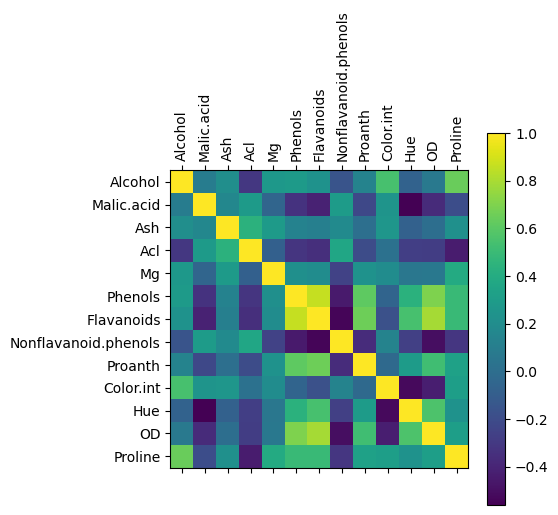

In [25]:
import matplotlib.pyplot as plt

plt.matshow(X.corr())
plt.xticks(range(len(X.columns)), X.columns, rotation=90)
plt.yticks(range(len(X.columns)), X.columns)
plt.colorbar()
plt.show()

In [21]:
#We start with scaling the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
display(X.describe())
display(X.info())

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic.acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Acl                   178 non-null    float64
 4   Mg                    178 non-null    int64  
 5   Phenols               178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid.phenols  178 non-null    float64
 8   Proanth               178 non-null    float64
 9   Color.int             178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD                    178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


None

In [34]:
kmeans_wine = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_wine.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [29]:
comparison_wine = pd.DataFrame({
    "Actual": y,
    "Cluster": kmeans_wine.labels_
})
pd.crosstab(comparison_wine["Actual"], comparison_wine["Cluster"])

Cluster,0,1,2
Actual,,,
1,13,46,0
2,20,1,50
3,29,0,19


In [35]:
kmeans_wine = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_wine.fit(X_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [36]:
comparison_wine = pd.DataFrame({
    "Actual":y,
    "Cluster":kmeans_wine.labels_
})
pd.crosstab(comparison_wine["Actual"], comparison_wine["Cluster"])

Cluster,0,1,2,3,4
Actual,,,,,
1,57,0,1,0,1
2,2,8,34,0,27
3,0,22,0,26,0


In [37]:
kmeans_wine = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_wine.fit(X_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [40]:
comparison_wine = pd.DataFrame({
    "Actual":y,
    "Cluster":kmeans_wine.labels_
})
pd.crosstab(comparison_wine["Actual"], comparison_wine["Cluster"])

Cluster,0,1
Actual,,
1,59,0
2,28,43
3,0,48


# Task 3: Weather AUS Dataset

In [41]:
w_aus = pandas.read_csv("Unit06-weatherAUS.csv")
w_aus.head() 

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No


In [46]:
X = w_aus.drop("RainTomorrow", axis=1)
y = w_aus["RainTomorrow"]
display(w_aus.shape)
display(y.value_counts())

(145460, 14)

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

In [51]:
#Checking for correlations between features
numerical_values = X.drop("RainToday", axis=1)
categorical_value = X["RainToday"]
correlation_matrix = numerical_values.corr()
correlation_matrix.round(2)

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
MinTemp,1.00,0.74,0.10,0.18,0.18,0.18,-0.23,0.01,-0.45,-0.46,0.90,0.71
MaxTemp,0.74,1.00,-0.07,0.07,0.01,0.05,-0.50,-0.51,-0.33,-0.43,0.89,0.98
Rainfall,0.10,-0.07,1.00,0.13,0.09,0.06,0.22,0.26,-0.17,-0.13,0.01,-0.08
WindGustSpeed,0.18,0.07,0.13,1.00,0.61,0.69,-0.22,-0.03,-0.46,-0.41,0.15,0.03
WindSpeed9am,0.18,0.01,0.09,0.61,1.00,0.52,-0.27,-0.03,-0.23,-0.18,0.13,0.00
WindSpeed3pm,0.18,0.05,0.06,0.69,0.52,1.00,-0.15,0.02,-0.30,-0.26,0.16,0.03
Humidity9am,-0.23,-0.50,0.22,-0.22,-0.27,-0.15,1.00,0.67,0.14,0.19,-0.47,-0.50
Humidity3pm,0.01,-0.51,0.26,-0.03,-0.03,0.02,0.67,1.00,-0.03,0.05,-0.22,-0.56
Pressure9am,-0.45,-0.33,-0.17,-0.46,-0.23,-0.30,0.14,-0.03,1.00,0.96,-0.42,-0.29
Pressure3pm,-0.46,-0.43,-0.13,-0.41,-0.18,-0.26,0.19,0.05,0.96,1.00,-0.47,-0.39


In [55]:
#Checking for missing values
(w_aus.isnull().sum() / len(w_aus) * 100).round(2)

MinTemp           1.02
MaxTemp           0.87
Rainfall          2.24
WindGustSpeed     7.06
WindSpeed9am      1.21
WindSpeed3pm      2.11
Humidity9am       1.82
Humidity3pm       3.10
Pressure9am      10.36
Pressure3pm      10.33
Temp9am           1.21
Temp3pm           2.48
RainToday         2.24
RainTomorrow      2.25
dtype: float64

In [ ]:
#Preprocessing
#1. Removing highly correlated features
X = X.drop(columns=[
    "Temp9am",
    "Temp3pm",
    "Pressure3pm"
])

In [61]:
#2. Turning categorical feature into a numeric, binary feature
X["RainToday"] = X["RainToday"].map({"No": 0, "Yes": 1})

In [63]:
#3. Median imputing features with missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [64]:
#4. Scaling numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [73]:
#Fitting the data with k=2
kmeans_w_aus_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_w_aus_2.fit(X_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [74]:
#Comparing with actual labels
comparison_waus = pd.DataFrame({
    "Actual":y,
    "Cluster":kmeans_w_aus_2.labels_
})
pd.crosstab(comparison_waus["Actual"], comparison_waus["Cluster"])

Cluster,0,1
Actual,,
No,54709,55607
Yes,16731,15146


In [75]:
#Fitting the data with k=6
kmeans_w_aus_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_w_aus_6.fit(X_scaled)

,n_clusters,6
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [76]:
#Comparing with actual labels
comparison_waus = pd.DataFrame({
    "Actual":y,
    "Cluster":kmeans_w_aus_6.labels_
})
pd.crosstab(comparison_waus["Actual"], comparison_waus["Cluster"])

Cluster,0,1,2,3,4,5
Actual,,,,,,
No,13048,12286,592,23098,34768,26524
Yes,10587,6605,1469,1519,5012,6685


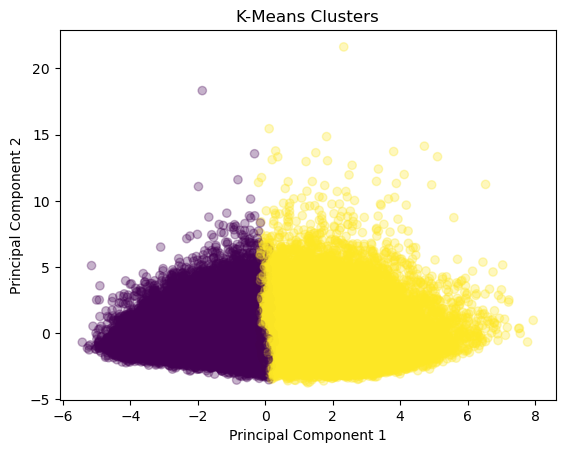

In [81]:
#Creating a 2D Scatter plot, first reducing the number of features with PCA - first for the K=2 model
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=kmeans_w_aus_2.labels_,
    alpha=0.3
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")
plt.show()

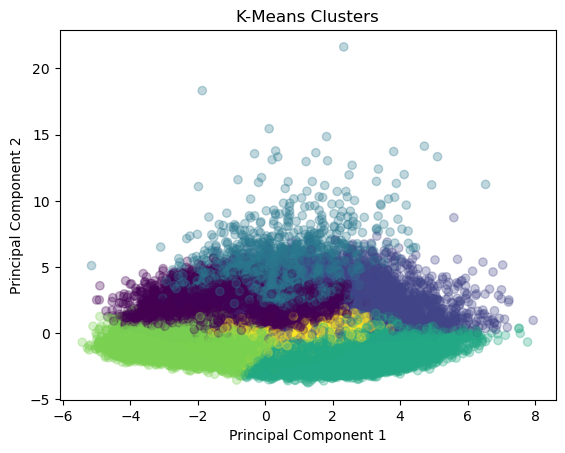

In [78]:
#Creating a 2D Scatter plot, first reducing the number of features with PCA - then for the K=6 model
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=kmeans_w_aus_6.labels_,
    alpha=0.3
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters")
plt.show()